In [1]:
!pip install tensorflow tensorflow-datasets polymahalanobis tqdm
!pip install "numpy<2.0" --quiet

DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Using cached numpy-2.4.6-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.6 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.6 which is

In [2]:
!pip install nvidia-cudnn-cu12==9.3.0.75

DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


I0000 00:00:1789073944.247460  174226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789073944.355475  174226 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789073947.188453  174226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789073952.897751  174226 gpu_device.cc:2043] Creat

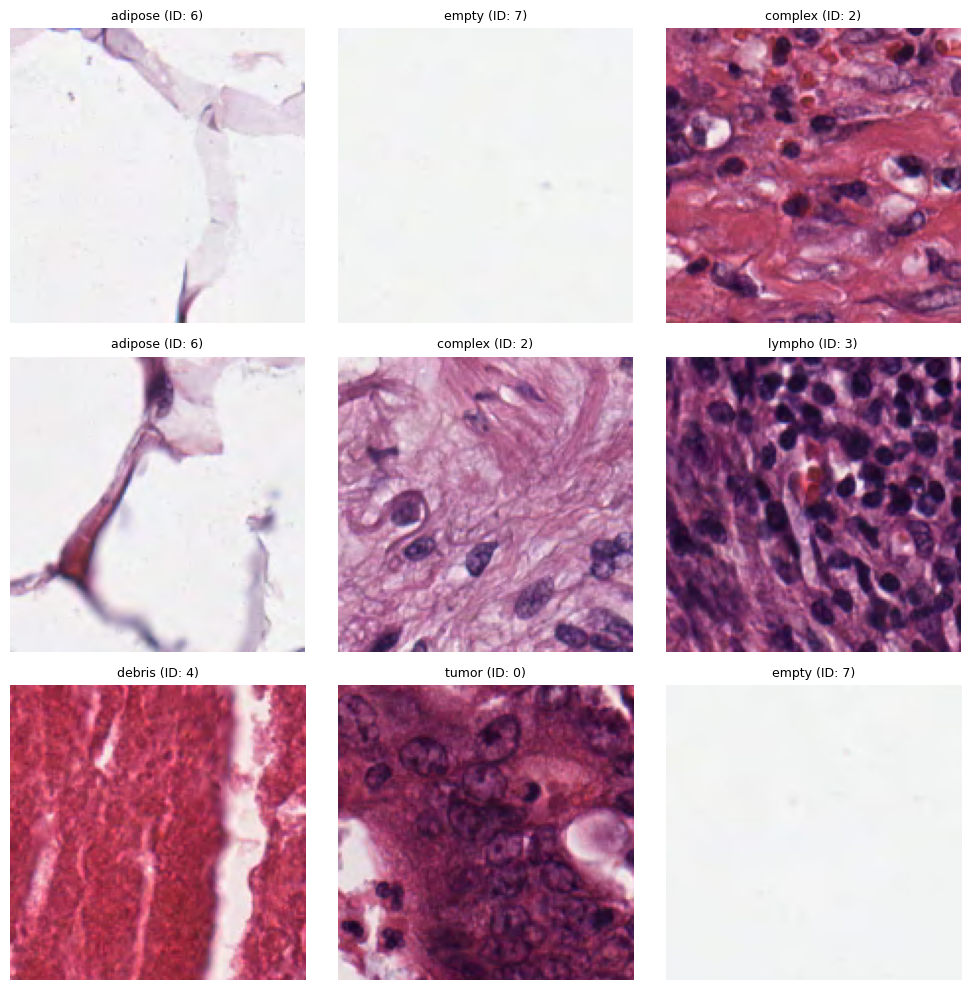

In [3]:
import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silencia logs informativos do TensorFlow
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# Desativa barras de progresso verbosas que estouram o IOPub
tfds.core.utils.tqdm_utils.disable_progress_bar()

# Carregamento com splits
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'colorectal_histology',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)

class_names = ds_info.features['label'].names

# Visualização de 9 amostras
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{class_names[label.numpy()]} (ID: {label.numpy()})", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

def preprocess(image, label, training=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

def make_pipeline(ds, training=False):
    ds = ds.map(lambda x, y: preprocess(x, y, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

cnn_train = make_pipeline(ds_train, training=True)
cnn_val   = make_pipeline(ds_val,   training=False)
cnn_test  = make_pipeline(ds_test,  training=False)

## Teste Resnet

In [5]:
from tensorflow.keras import layers, models, callbacks


def conv_bn_relu(x, filters, kernel_size, strides=1):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def residual_block(x, filters, strides=1):
    shortcut = x
    y = conv_bn_relu(x, filters, 3, strides=strides)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    y = layers.Add()([shortcut, y])
    y = layers.ReLU()(y)
    return y


def build_resnet18(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = conv_bn_relu(inputs, 64, 7, strides=2)
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    x = residual_block(x, 64, strides=1)
    x = residual_block(x, 64, strides=1)

    x = residual_block(x, 128, strides=2)
    x = residual_block(x, 128, strides=1)

    x = residual_block(x, 256, strides=2)
    x = residual_block(x, 256, strides=1)

    x = residual_block(x, 512, strides=2)
    x = residual_block(x, 512, strides=1)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="resnet18")


resnet_model = build_resnet18()
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
resnet_model.summary()


E0000 00:00:1789073957.368256  175175 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.4.131, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


Model: "resnet18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]  

 Total params: 11,190,216 (42.69 MB)

 Trainable params: 11,180,616 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
early_stop_resnet = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8, restore_best_weights=True
)
reduce_lr_resnet = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6
)

EPOCHS = 100

history_resnet = resnet_model.fit(
    cnn_train,
    validation_data=cnn_val,
    epochs=EPOCHS,
    callbacks=[early_stop_resnet, reduce_lr_resnet],
)

resnet_model.save("resnet18_colorectal.keras")   


Epoch 1/100


/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8832 - loss: 0.3058 - val_accuracy: 0.8180 - val_loss: 0.4053 - learning_rate: 2.5000e-04
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8947 - loss: 0.2768 - val_accuracy: 0.5740 - val_loss: 2.4834 - learning_rate: 2.5000e-04
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8997 - loss: 0.2705 - val_accuracy: 0.8260 - val_loss: 0.5647 - learning_rate: 2.5000e-04
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9068 - loss: 0.2522 - val_accuracy: 0.6800 - val_loss: 1.0655 - learning_rate: 2.5000e-04
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9057 - loss: 0.2550 - val_accuracy: 0.8420 - val_loss: 0.4602 - learning_rate: 2.5000e-04
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9168 - loss: 0.2251 - val_accuracy: 0.6720 - val_loss: 2.1853 - learning_rate: 1.2500e-04
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy

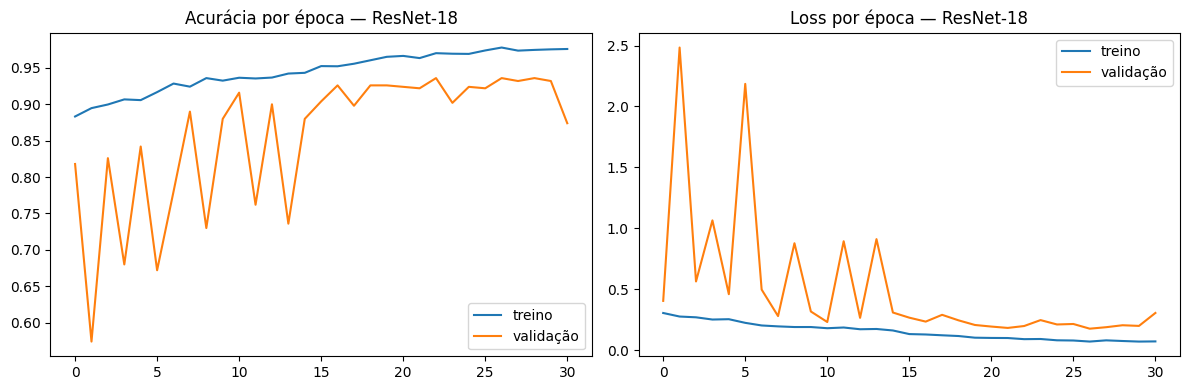

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_resnet.history["accuracy"], label="treino")
axes[0].plot(history_resnet.history["val_accuracy"], label="validação")
axes[0].set_title("Acurácia por época — ResNet-18")
axes[0].legend()

axes[1].plot(history_resnet.history["loss"], label="treino")
axes[1].plot(history_resnet.history["val_loss"], label="validação")
axes[1].set_title("Loss por época — ResNet-18")
axes[1].legend()
plt.tight_layout()
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
=== ResNet-18 — Desempenho na Validação ===
Acurácia: 93.60%

              precision    recall  f1-score   support

       tumor       0.95      0.93      0.94        45
      stroma       0.82      0.94      0.88        69
     complex       0.86      0.86      0.86        69
      lympho       0.97      0.90      0.93        63
      debris       0.96      0.91      0.94        58
      mucosa       1.00      0.97      0.99        68
     adipose       1.00      0.97      0.98        61
       empty       0.97      1.00      0.99        67

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



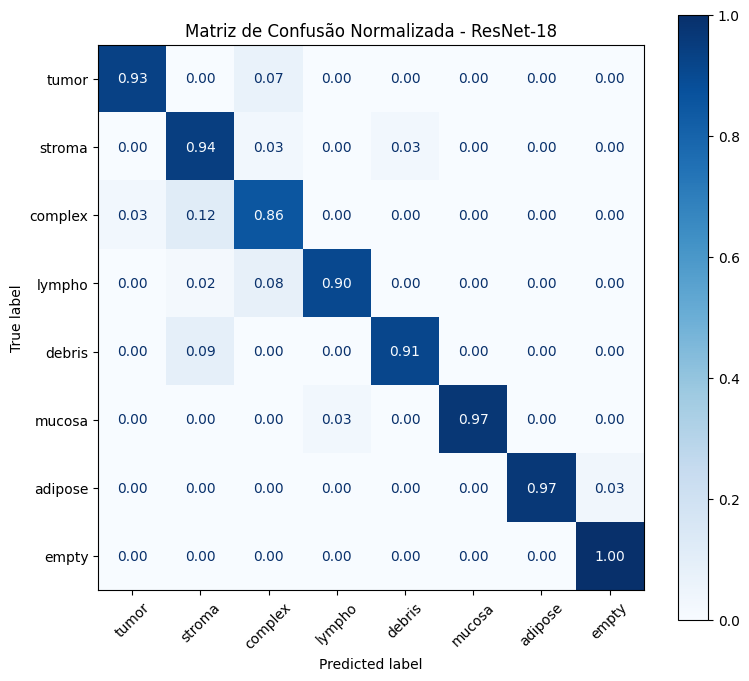

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true_resnet = np.concatenate([y.numpy() for _, y in cnn_val], axis=0)
y_prob_resnet = resnet_model.predict(cnn_val)
y_pred_resnet = np.argmax(y_prob_resnet, axis=1)

acc_resnet = np.mean(y_pred_resnet == y_true_resnet) * 100
print("=== ResNet-18 — Desempenho na Validação ===")
print(f"Acurácia: {acc_resnet:.2f}%\n")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 7))
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_names)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Matriz de Confusão Normalizada - ResNet-18")
plt.tight_layout()
plt.show()


## Teste Yolo

In [9]:
import shutil
from pathlib import Path

from PIL import Image
from ultralytics import YOLO

YOLO_ROOT = Path("yolo_cls")
YOLO_MODEL_NAME = "yolo11n-cls.pt"


def export_tfds_split(ds, split_name):
    for class_name in class_names:
        (YOLO_ROOT / split_name / class_name).mkdir(parents=True, exist_ok=True)
    counts = {name: 0 for name in class_names}
    for image, label in ds:
        label_idx = int(label.numpy())
        class_name = class_names[label_idx]
        counts[class_name] += 1
        out_path = YOLO_ROOT / split_name / class_name / f"{counts[class_name]:05d}.png"
        arr = image.numpy()
        Image.fromarray(arr).save(out_path)


if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

export_tfds_split(ds_train, "train")
export_tfds_split(ds_val, "val")
print("Dataset YOLO exportado em", YOLO_ROOT.resolve())


Dataset YOLO exportado em /home/jovyan/privado/yolo_cls


In [10]:
yolo_model = YOLO(YOLO_MODEL_NAME)
yolo_results = yolo_model.train(
    data=str(YOLO_ROOT),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=8,
    project="yolo_runs",
    name="colorectal_yolo11",
    exist_ok=True,
    verbose=True,
)


New https://pypi.org/project/ultralytics/8.4.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.33 🚀 Python-3.11.10 torch-2.5.1+cu124 CUDA:0 (NVIDIA H100 80GB HBM3, 81089MiB)
engine/trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=yolo_cls, epochs=100, time=None, patience=8, batch=32, imgsz=128, save=True, save_period=-1, cache=False, device=None, workers=8, project=yolo_runs, name=colorectal_yolo11, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fa

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs.neptune.ai/logging/source_code/


AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅


train: Scanning /home/jovyan/privado/yolo_cls/train... 4000 images, 0 corrupt: 100%|██████████| 4000/4000 [00:01<00:00, 2566.54it/s]


train: New cache created: /home/jovyan/privado/yolo_cls/train.cache


...

     78/100     0.216G    0.06208         32        128: 100%|██████████| 125/125 [00:07<00:00, 17.77it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 8/8 [00:00<00:00, 37.57it/s]

                   all       0.97          1
EarlyStopping: Training stopped early as no improvement observed in last 8 epochs. Best results observed at epoch 70, best model saved as best.pt.
To update EarlyStopping(patience=8) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



78 epochs completed in 0.189 hours.
Optimizer stripped from yolo_runs/colorectal_yolo11/weights/last.pt, 3.2MB
Optimizer stripped from yolo_runs/colorectal_yolo11/weights/best.pt, 3.2MB

Validating yolo_runs/colorectal_yolo11/weights/best.pt...
Ultralytics 8.3.33 🚀 Python-3.11.10 torch-2.5.1+cu124 CUDA:0 (NVIDIA H100 80GB HBM3, 81089MiB)
YOLO11n-cls summary (fused): 112 layers, 1,536,272 parameters, 0 gradients, 3.2 GFLOPs
train: /home/jovyan/privado/yolo_cls/train... found 4000 images in 8 classes ✅ 
val: /home/jovyan/privado/yolo_cls/val... found 500 images in 8 classes ✅ 
test: None...


               classes   top1_acc   top5_acc: 100%|██████████| 8/8 [00:00<00:00, 24.36it/s]


                   all       0.98          1
Speed: 0.1ms preprocess, 0.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to yolo_runs/colorectal_yolo11


=== YOLO11 — Desempenho na Validação ===
Acurácia: 98.00%

              precision    recall  f1-score   support

       tumor       0.98      0.98      0.98        45
      stroma       0.97      0.99      0.98        69
     complex       0.96      0.94      0.95        69
      lympho       0.95      0.98      0.97        63
      debris       1.00      0.98      0.99        58
      mucosa       1.00      0.99      0.99        68
     adipose       1.00      0.98      0.99        61
       empty       0.99      1.00      0.99        67

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



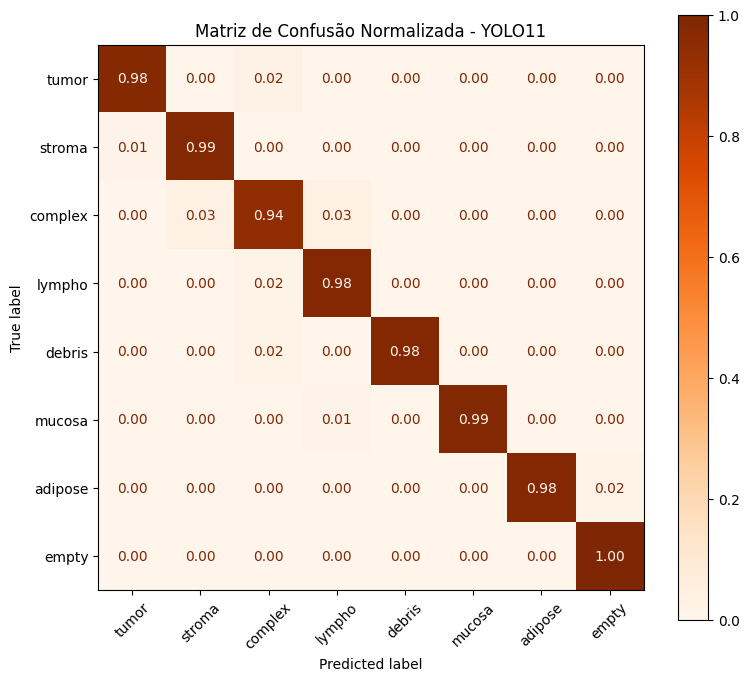

In [11]:
best_yolo = YOLO("yolo_runs/colorectal_yolo11/weights/best.pt")
yolo_idx_to_name = best_yolo.names
name_to_true_idx = {name: i for i, name in enumerate(class_names)}

y_true_yolo = []
y_pred_yolo = []
val_root = YOLO_ROOT / "val"
for class_idx, class_name in enumerate(class_names):
    class_dir = val_root / class_name
    image_paths = sorted(str(p) for p in class_dir.glob("*.png"))
    if not image_paths:
        continue
    preds = best_yolo.predict(source=image_paths, imgsz=IMG_SIZE, verbose=False)
    for pred in preds:
        y_true_yolo.append(class_idx)
        pred_name = yolo_idx_to_name[int(pred.probs.top1)]
        y_pred_yolo.append(name_to_true_idx[pred_name])

y_true_yolo = np.array(y_true_yolo)
y_pred_yolo = np.array(y_pred_yolo)

acc_yolo = np.mean(y_pred_yolo == y_true_yolo) * 100
print("=== YOLO11 — Desempenho na Validação ===")
print(f"Acurácia: {acc_yolo:.2f}%\n")
print(classification_report(y_true_yolo, y_pred_yolo, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 7))
cm_yolo = confusion_matrix(y_true_yolo, y_pred_yolo, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_yolo, display_labels=class_names)
disp.plot(cmap="Oranges", ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Matriz de Confusão Normalizada - YOLO11")
plt.tight_layout()
plt.show()
